初始化分析器...
计算技术指标...
提取模式特征...
执行K线模式聚类分析...
K线模式聚类分析报告

1. 基本统计信息:
   总K线数量: 100
   窗口大小: 15

2. 模式聚类分析:
开始模式聚类...
提取窗口特征...
聚类完成，共识别出 66 个有效模式
   有效模式窗口: 66
   轮廓系数: 0.4065
   聚类数量: 8
   簇0 - 上升初期:
     模式数量: 22
     平均价格变化: 3.37%
     平均波动率: 1.85%
     平均RSI: 67.1
     摆动高点: 2.6
     摆动低点: 0.9
   簇1 - 上升初期:
     模式数量: 4
     平均价格变化: 8.92%
     平均波动率: 2.09%
     平均RSI: 52.9
     摆动高点: 1.5
     摆动低点: 2.0
   簇2 - 其他模式:
     模式数量: 6
     平均价格变化: -1.89%
     平均波动率: 3.37%
     平均RSI: 60.0
     摆动高点: 3.0
     摆动低点: 1.3
   簇3 - 盘整:
     模式数量: 6
     平均价格变化: 0.61%
     平均波动率: 1.59%
     平均RSI: 37.6
     摆动高点: 0.7
     摆动低点: 2.0
   簇4 - 上升初期:
     模式数量: 10
     平均价格变化: 2.78%
     平均波动率: 1.14%
     平均RSI: 66.2
     摆动高点: 1.8
     摆动低点: 2.0
   簇5 - 上升3推:
     模式数量: 7
     平均价格变化: 4.58%
     平均波动率: 1.53%
     平均RSI: 59.3
     摆动高点: 2.0
     摆动低点: 1.0
   簇6 - 强势上升:
     模式数量: 5
     平均价格变化: 3.44%
     平均波动率: 1.49%
     平均RSI: 46.4
     摆动高点: 2.0
     摆动低点: 1.0
   簇7 - 上升初期:
     模式数量: 6
     平均价格变

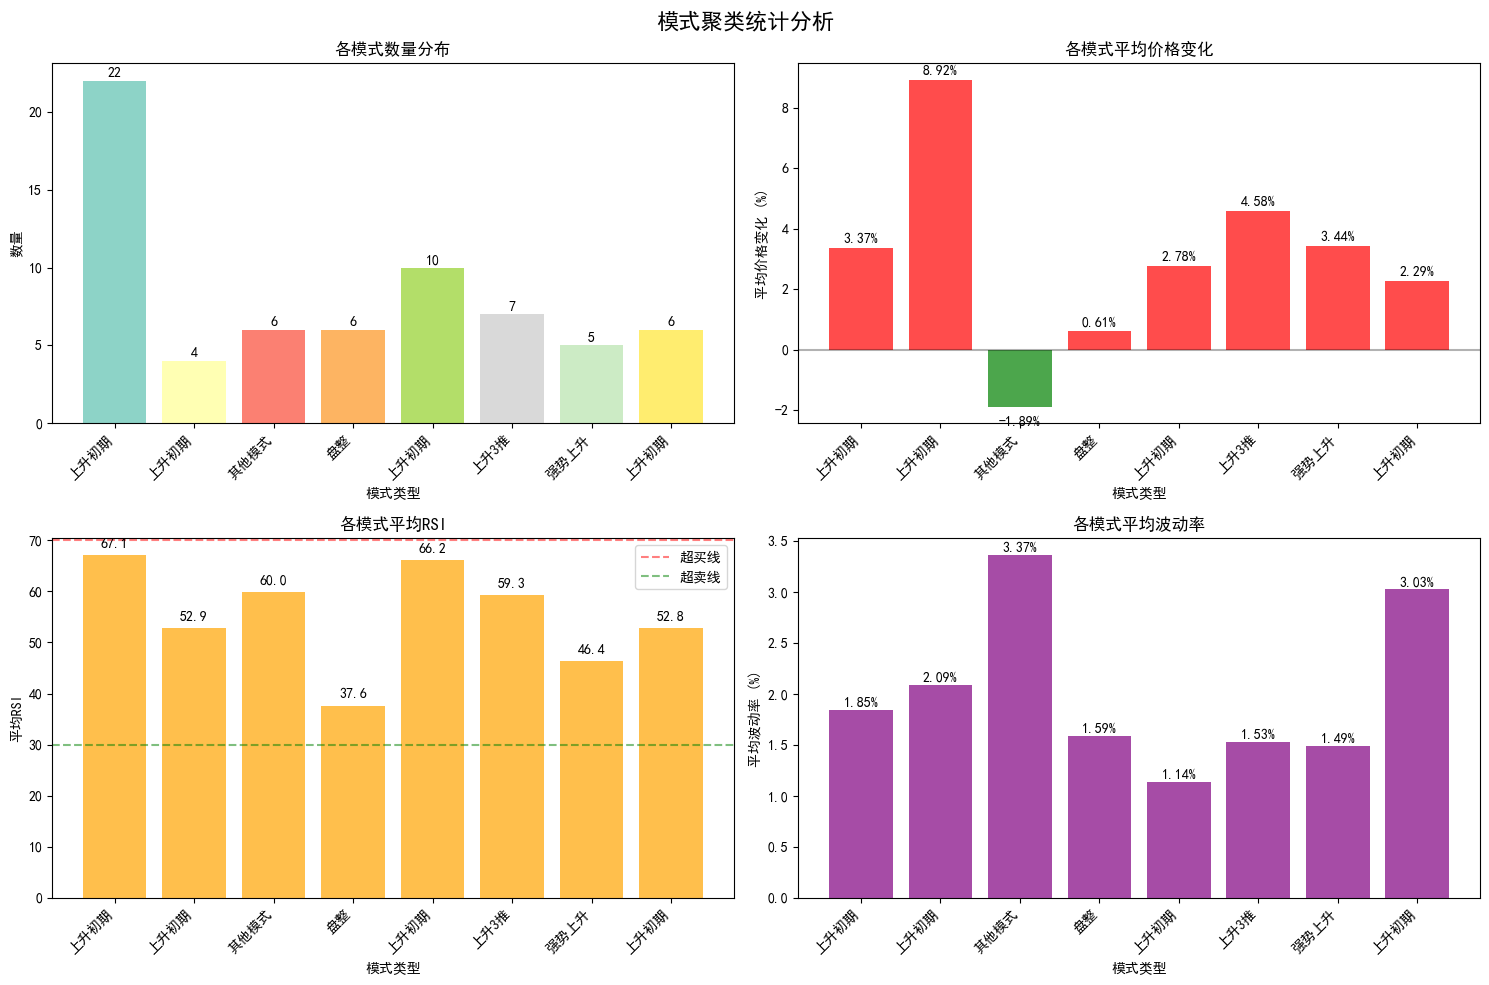

绘制价格序列与模式标记...


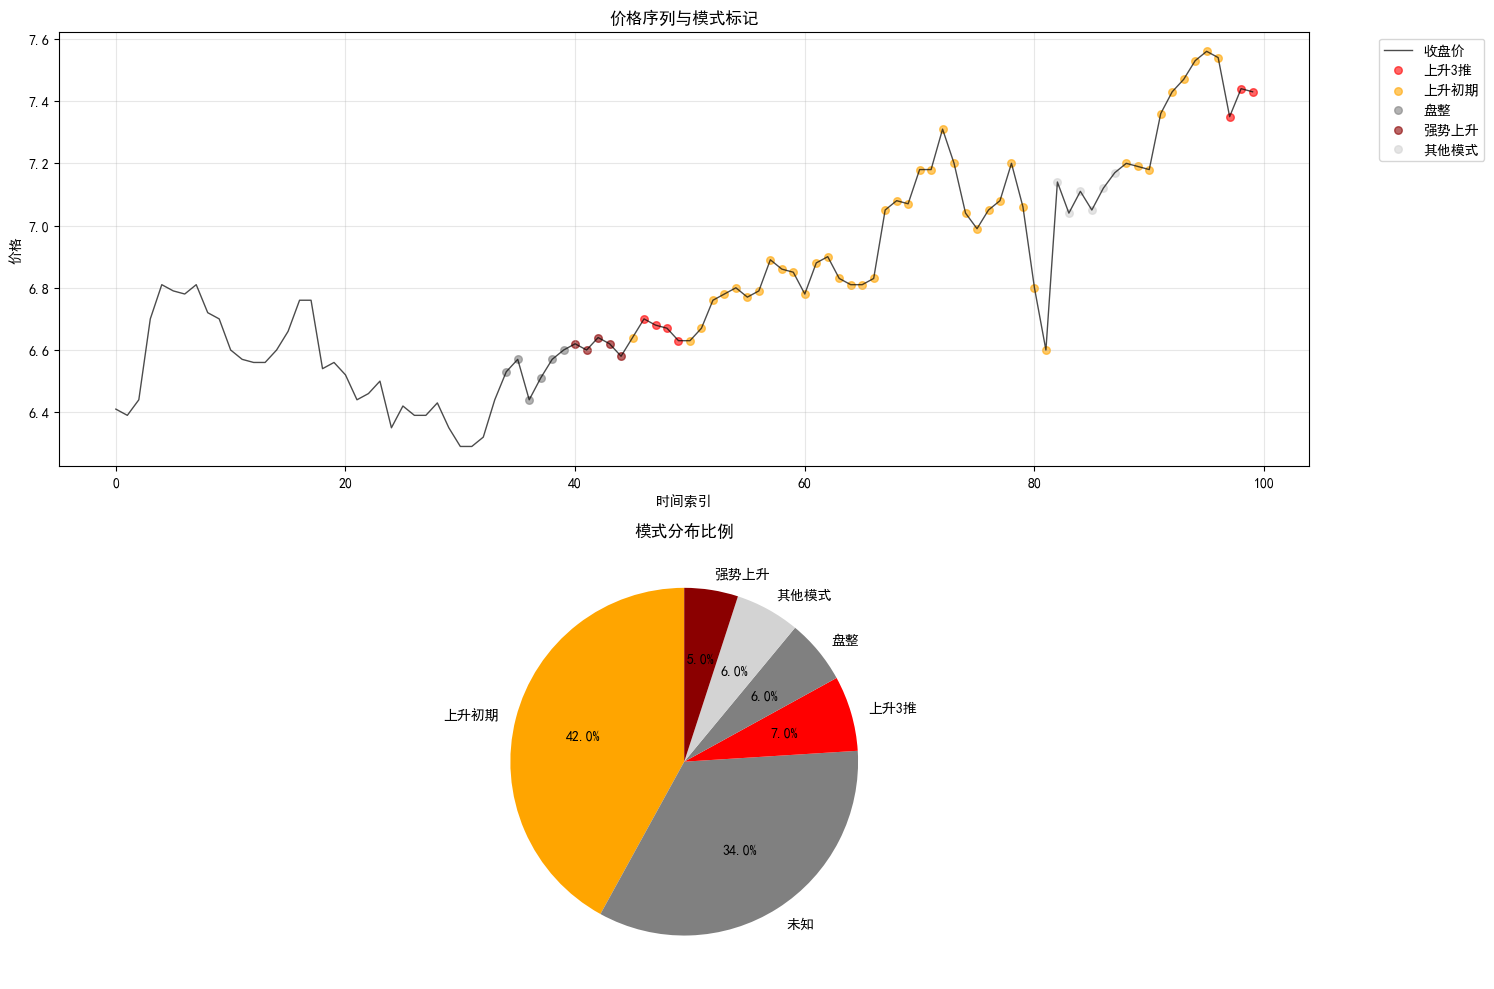

绘制模式示例...


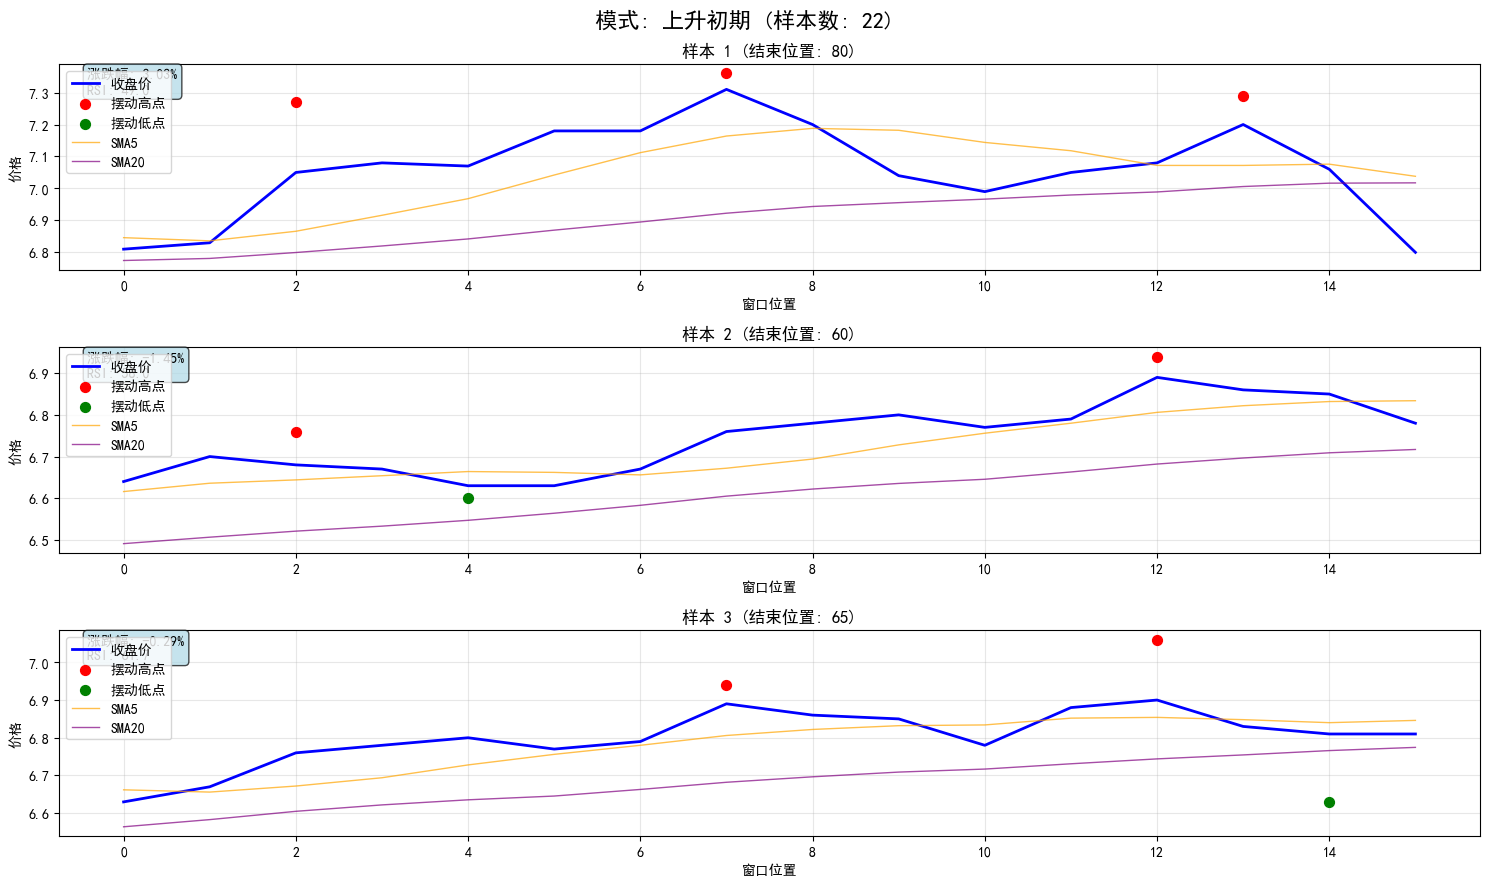

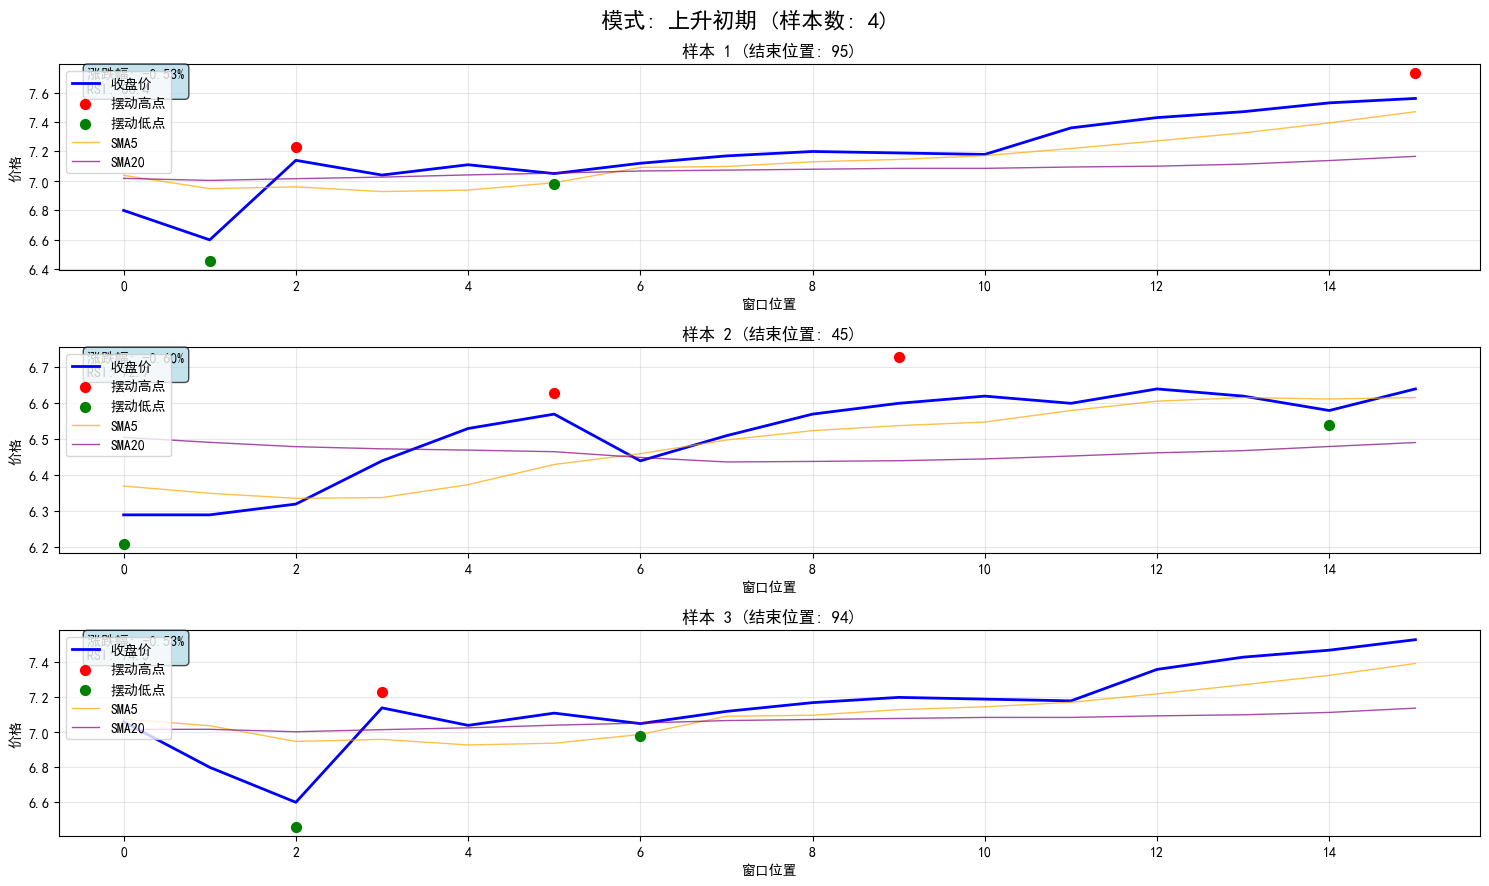

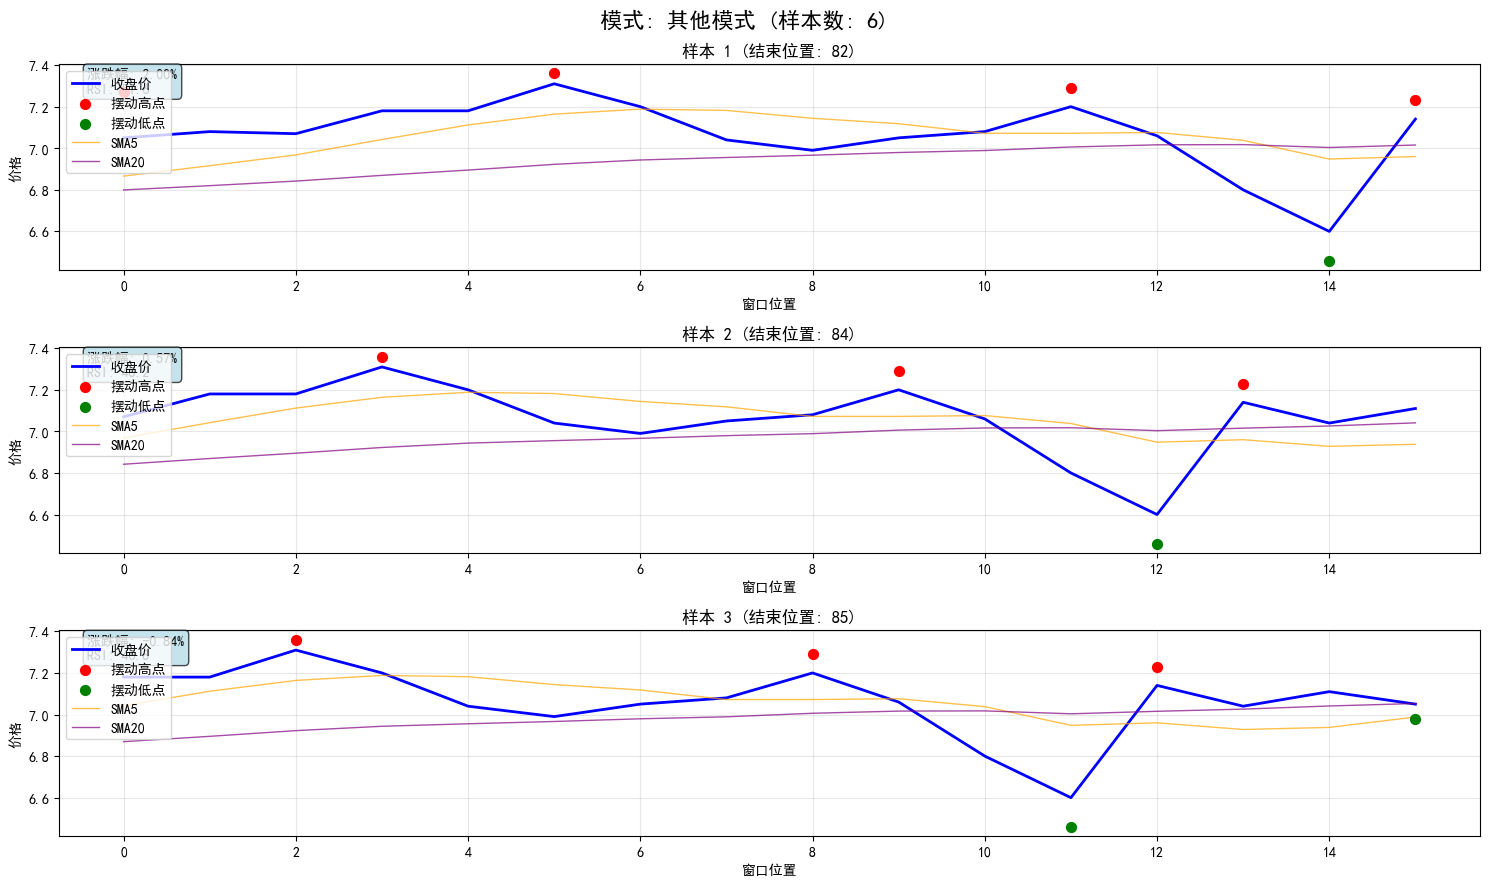

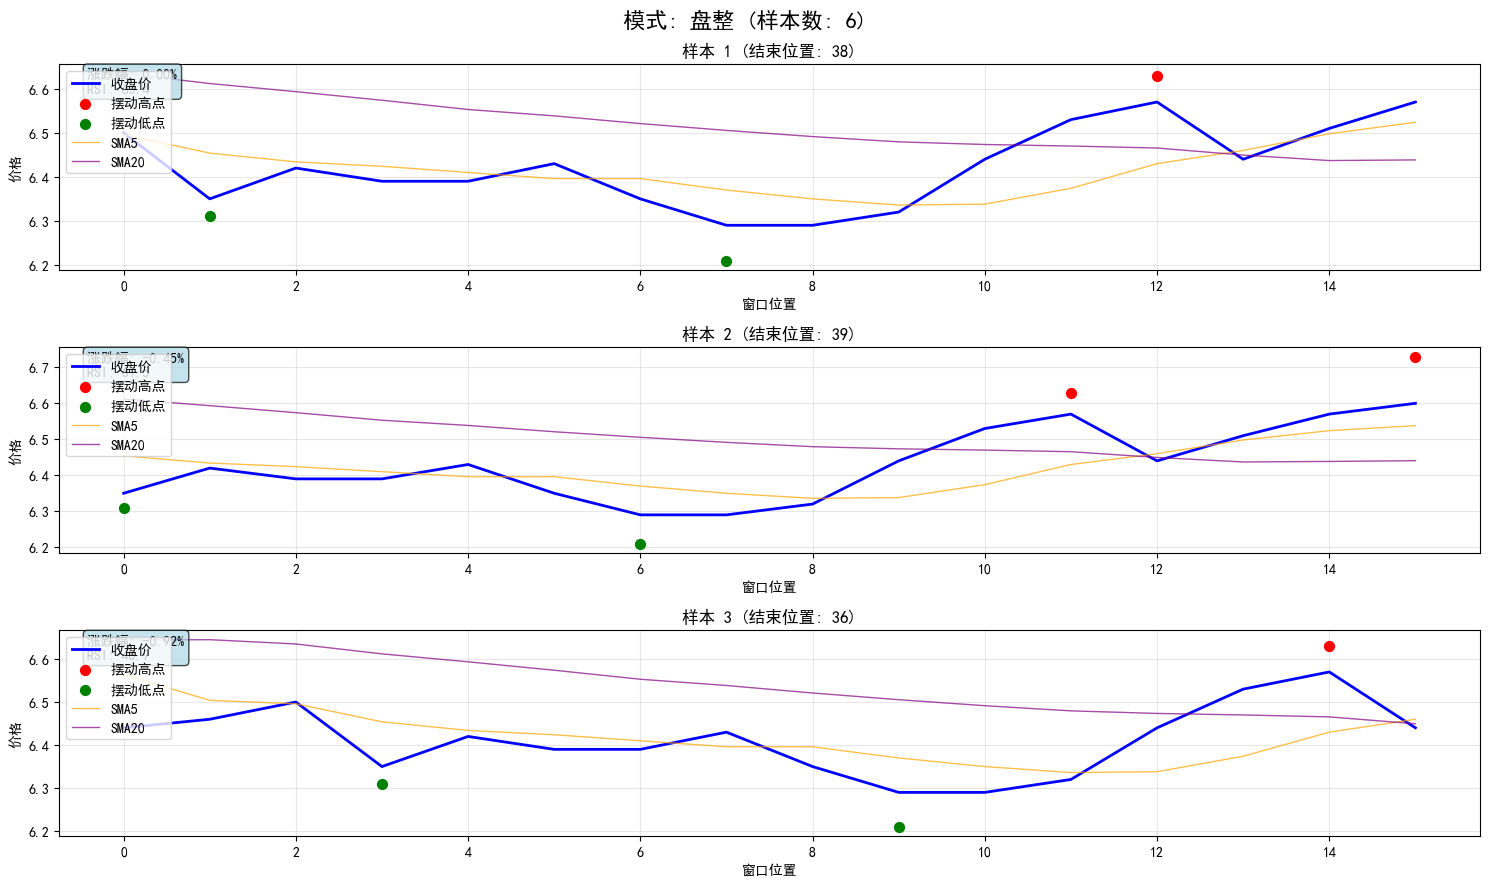

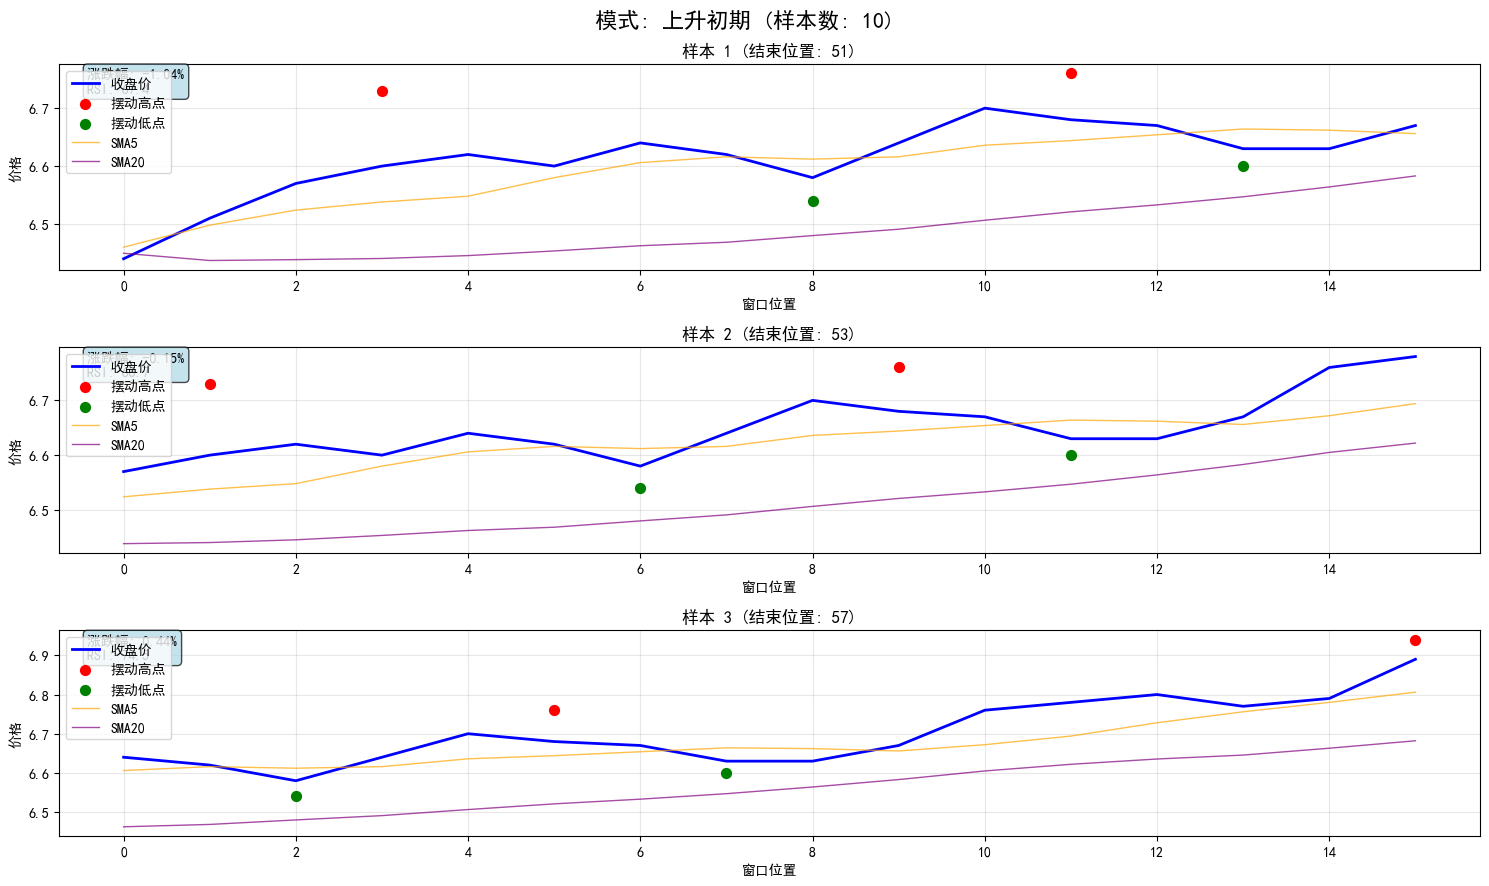

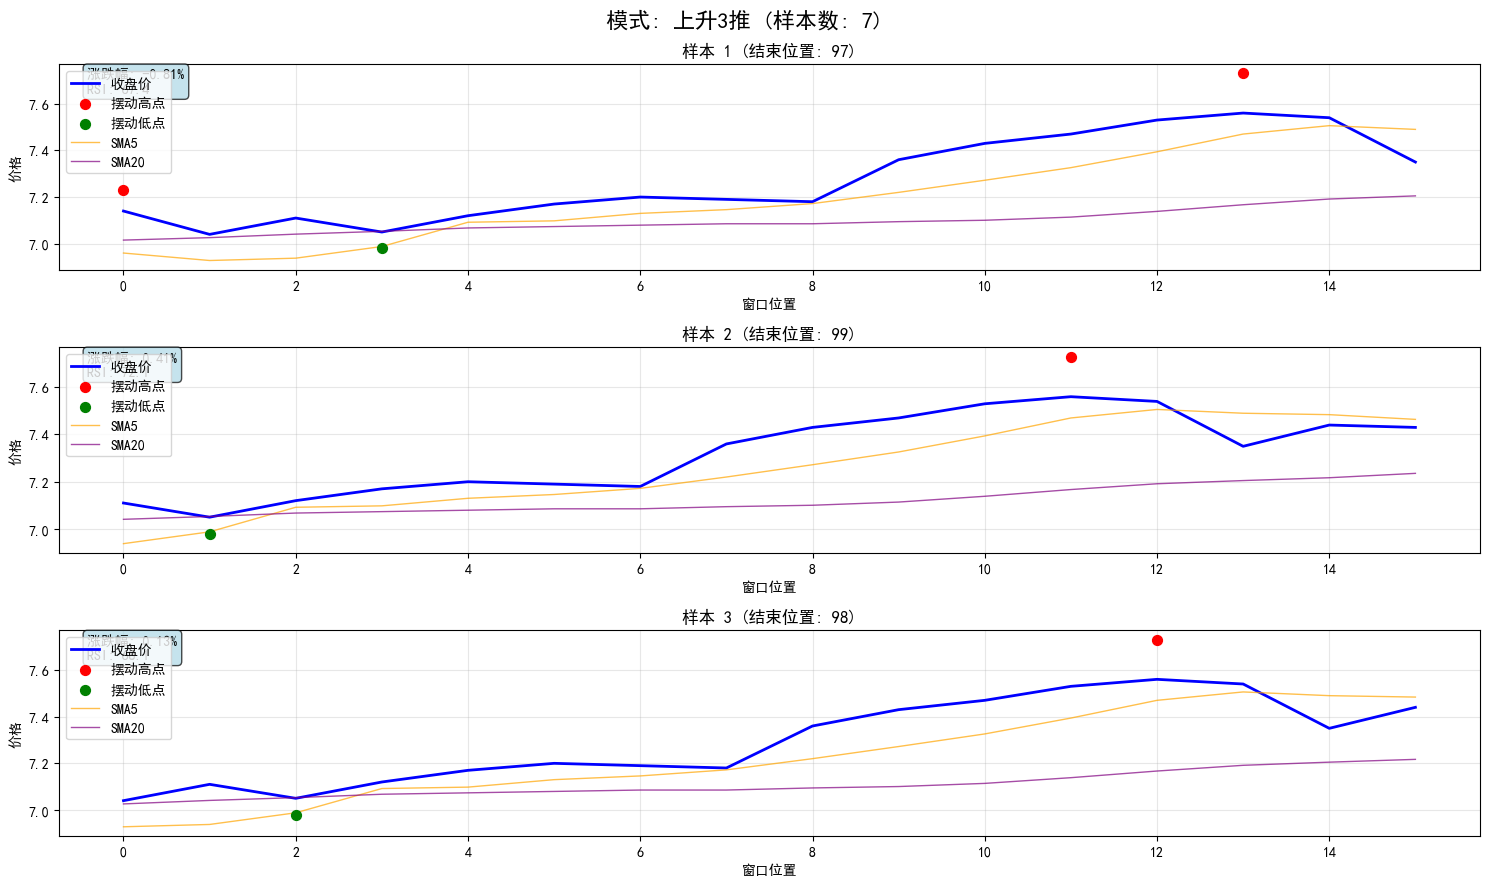

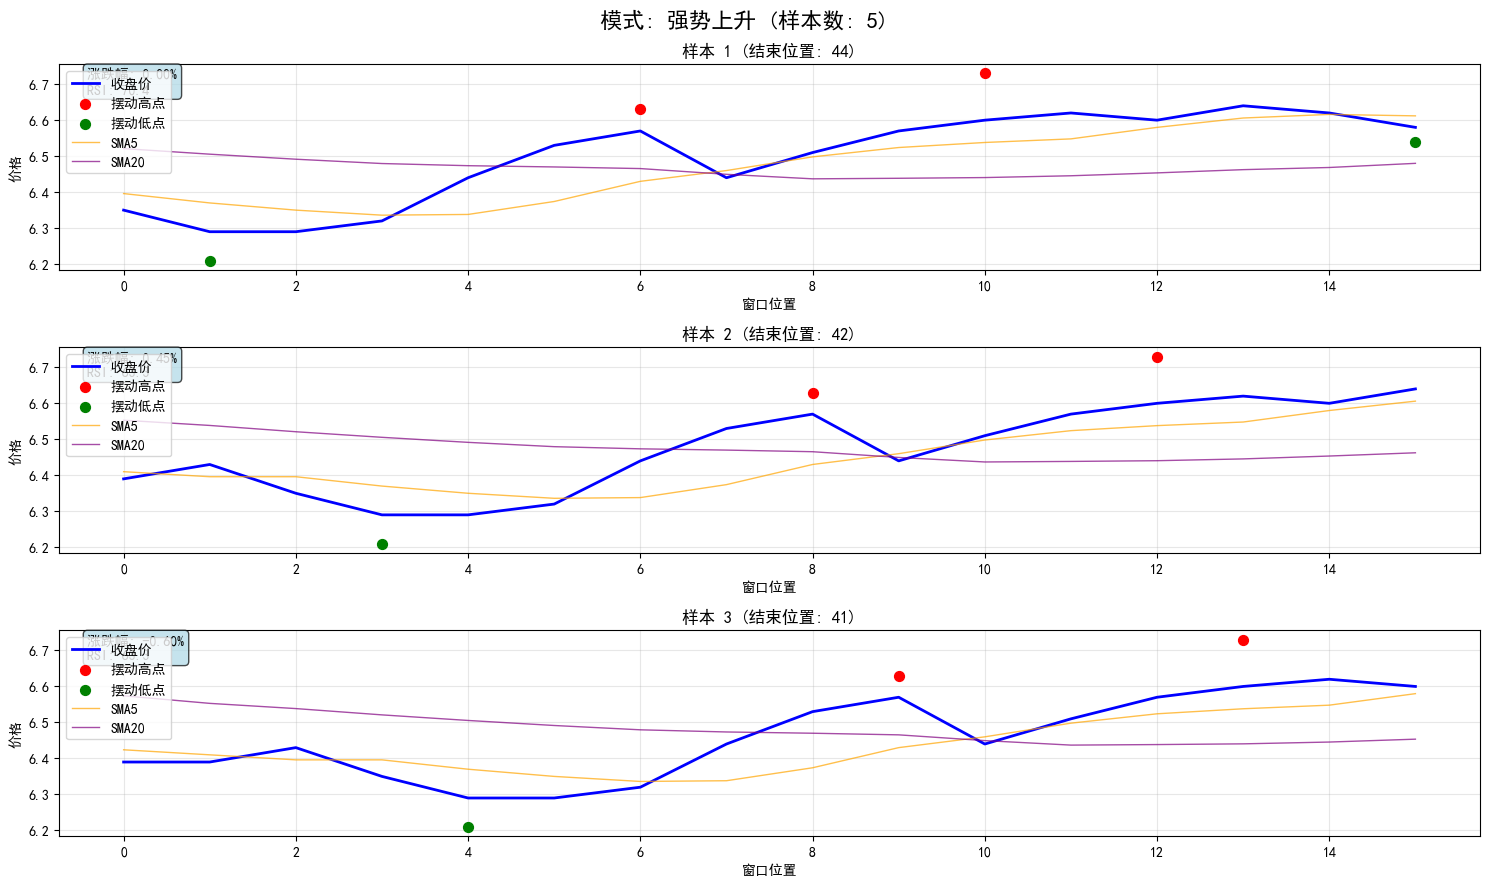

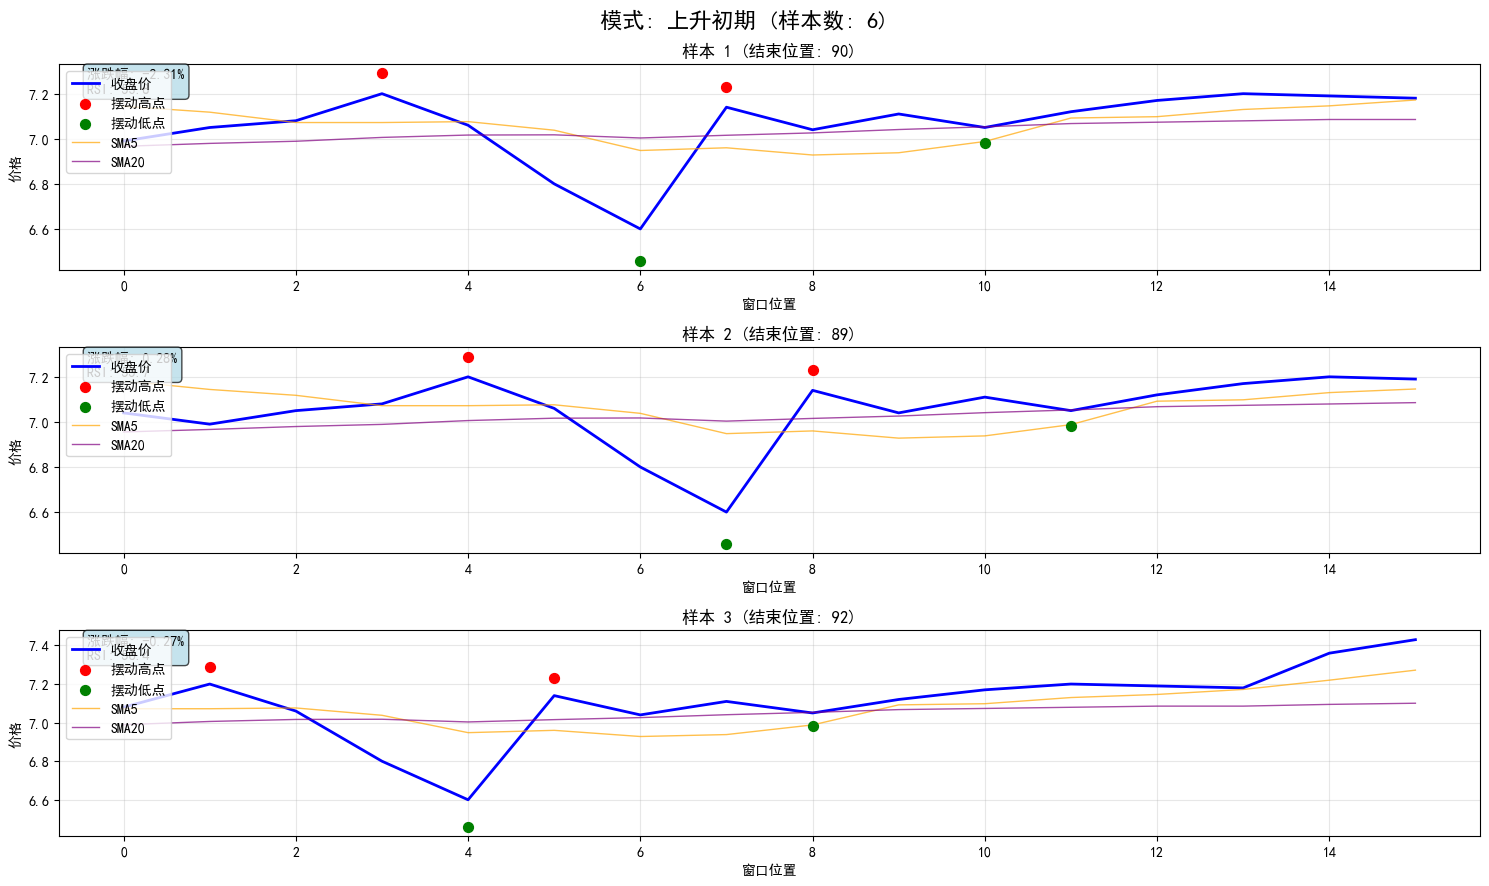

K线模式聚类分析完成！


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import os
warnings.filterwarnings('ignore')

# 设置中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

class PatternClusterAnalyzer:
    
    def __init__(self, csv_file, window_size=15):
        """
        初始化模式聚类分析器
        
        参数:
        csv_file: OHLC数据文件路径
        window_size: 用于模式识别的窗口大小
        """
        self.df = pd.read_csv(csv_file, nrows=100)
        self.window_size = window_size
        
        # 确保列名是小写
        self.df.columns = self.df.columns.str.lower()
        
        # 检查必要的列是否存在
        required_columns = ['open', 'high', 'low', 'close']
        missing_columns = [col for col in required_columns if col not in self.df.columns]
        
        if missing_columns:
            raise ValueError(f"缺少必要的列: {missing_columns}")
        
        # 初始化聚类结果列
        self.df['pattern_cluster'] = -1
        self.df['pattern_type'] = '未知'
        
        # 计算技术指标和模式特征
        self._calculate_technical_indicators()
        self._extract_pattern_features()
        
    def _calculate_technical_indicators(self):
        """计算技术指标"""
        print("计算技术指标...")
        
        # 价格变化
        self.df['price_change'] = self.df['close'] - self.df['open']
        self.df['price_change_pct'] = self.df['price_change'] / self.df['open'] * 100
        
        # 简单移动平均
        self.df['sma_5'] = self.df['close'].rolling(window=5).mean()
        self.df['sma_10'] = self.df['close'].rolling(window=10).mean()
        self.df['sma_20'] = self.df['close'].rolling(window=20).mean()
        
        # 相对强弱指标 (RSI)
        self.df['rsi_14'] = self._calculate_rsi(self.df['close'], 14)
        
        # 布林带
        self.df['bb_middle'] = self.df['close'].rolling(window=20).mean()
        bb_std = self.df['close'].rolling(window=20).std()
        self.df['bb_upper'] = self.df['bb_middle'] + 2 * bb_std
        self.df['bb_lower'] = self.df['bb_middle'] - 2 * bb_std
        
        # 价格相对于布林带的位置
        self.df['bb_position'] = (self.df['close'] - self.df['bb_lower']) / (self.df['bb_upper'] - self.df['bb_lower'] + 1e-8)
        
        # 波动率
        self.df['volatility'] = self.df['high'] - self.df['low']
        self.df['volatility_pct'] = self.df['volatility'] / self.df['open'] * 100
        
        # 成交量相关 (如果有成交量数据)
        if 'volume' in self.df.columns:
            self.df['volume_sma'] = self.df['volume'].rolling(window=10).mean()
            self.df['volume_ratio'] = self.df['volume'] / self.df['volume_sma']
        
    def _calculate_rsi(self, prices, window=14):
        """计算RSI指标"""
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / (loss + 1e-8)  # 避免除以零
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    def _extract_pattern_features(self):
        """提取模式特征"""
        print("提取模式特征...")
        
        # 趋势特征
        self.df['trend_5'] = self.df['close'].rolling(window=5).apply(
            lambda x: 1 if x.iloc[-1] > x.iloc[0] else -1, raw=False)
        
        self.df['trend_10'] = self.df['close'].rolling(window=10).apply(
            lambda x: 1 if x.iloc[-1] > x.iloc[0] else -1, raw=False)
        
        # 动量特征
        self.df['momentum_5'] = self.df['close'].pct_change(periods=5)
        self.df['momentum_10'] = self.df['close'].pct_change(periods=10)
        
        # 价格位置特征
        self.df['position_in_range'] = (self.df['close'] - self.df['low']) / (self.df['high'] - self.df['low'] + 1e-8)
        
        # 波动特征
        self.df['volatility_trend'] = self.df['volatility_pct'].rolling(window=5).apply(
            lambda x: 1 if x.iloc[-1] > x.iloc[0] else -1, raw=False)
        
        # 支撑阻力特征
        self.df['distance_to_bb_upper'] = (self.df['bb_upper'] - self.df['close']) / (self.df['close'] + 1e-8)
        self.df['distance_to_bb_lower'] = (self.df['close'] - self.df['bb_lower']) / (self.df['close'] + 1e-8)
        
        # 多时间框架特征
        self.df['ma_relation'] = self._calculate_ma_relation()
        
        # 价格模式特征
        self.df['swing_high'] = self._identify_swing_highs()
        self.df['swing_low'] = self._identify_swing_lows()
        
    def _calculate_ma_relation(self):
        """计算移动平均线关系"""
        # 短期均线在长期均线之上为1，反之为-1
        ma_relation = []
        for i in range(len(self.df)):
            if pd.isna(self.df['sma_5'].iloc[i]) or pd.isna(self.df['sma_20'].iloc[i]):
                ma_relation.append(0)
            elif self.df['sma_5'].iloc[i] > self.df['sma_20'].iloc[i]:
                ma_relation.append(1)
            else:
                ma_relation.append(-1)
        return ma_relation
    
    def _identify_swing_highs(self, lookback=3):
        """识别摆动高点"""
        swing_highs = []
        for i in range(len(self.df)):
            if i < lookback or i >= len(self.df) - lookback:
                swing_highs.append(0)
                continue
                
            is_high = True
            current_high = self.df['high'].iloc[i]
            
            # 检查前后lookback周期内是否是最高点
            for j in range(1, lookback+1):
                if self.df['high'].iloc[i-j] >= current_high or self.df['high'].iloc[i+j] >= current_high:
                    is_high = False
                    break
            
            swing_highs.append(1 if is_high else 0)
        
        return swing_highs
    
    def _identify_swing_lows(self, lookback=3):
        """识别摆动低点"""
        swing_lows = []
        for i in range(len(self.df)):
            if i < lookback or i >= len(self.df) - lookback:
                swing_lows.append(0)
                continue
                
            is_low = True
            current_low = self.df['low'].iloc[i]
            
            # 检查前后lookback周期内是否是最低点
            for j in range(1, lookback+1):
                if self.df['low'].iloc[i-j] <= current_low or self.df['low'].iloc[i+j] <= current_low:
                    is_low = False
                    break
            
            swing_lows.append(1 if is_low else 0)
        
        return swing_lows
    
    def extract_window_features(self, window_size=10):
        """提取窗口特征用于模式识别"""
        print("提取窗口特征...")
        features = []
        valid_indices = []
        
        for i in range(window_size, len(self.df)):
            window_data = self.df.iloc[i-window_size:i]
            
            # 跳过包含NaN的窗口
            if window_data.isnull().any().any():
                continue
            
            # 窗口特征
            window_features = []
            
            # 1. 价格变化特征
            price_start = window_data['close'].iloc[0]
            price_end = window_data['close'].iloc[-1]
            price_change = (price_end - price_start) / price_start * 100
            window_features.append(price_change)
            
            # 2. 波动特征
            avg_volatility = window_data['volatility_pct'].mean()
            window_features.append(avg_volatility)
            
            # 3. 趋势特征
            trend_strength = window_data['trend_5'].mean()
            window_features.append(trend_strength)
            
            # 4. 动量特征
            momentum = window_data['momentum_5'].mean()
            window_features.append(momentum)
            
            # 5. RSI特征
            rsi_avg = window_data['rsi_14'].mean()
            window_features.append(rsi_avg)
            
            # 6. 布林带位置
            bb_position_avg = window_data['bb_position'].mean()
            window_features.append(bb_position_avg)
            
            # 7. 摆动点特征
            swing_high_count = window_data['swing_high'].sum()
            swing_low_count = window_data['swing_low'].sum()
            window_features.extend([swing_high_count, swing_low_count])
            
            # 8. 移动平均关系
            ma_relation_avg = window_data['ma_relation'].mean()
            window_features.append(ma_relation_avg)
            
            # 9. 成交量特征 (如果有)
            if 'volume_ratio' in self.df.columns:
                volume_ratio_avg = window_data['volume_ratio'].mean()
                window_features.append(volume_ratio_avg)
            
            features.append(window_features)
            valid_indices.append(i)
        
        return np.array(features), valid_indices
    
    def pattern_clustering(self, n_clusters=5):
        """模式聚类分析"""
        print("开始模式聚类...")
        
        # 提取窗口特征
        features, valid_indices = self.extract_window_features(self.window_size)
        
        if len(features) < n_clusters:
            raise ValueError(f"样本数量({len(features)})少于聚类数量({n_clusters})")
        
        # 标准化特征
        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)
        
        # 使用K-means聚类
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(features_scaled)
        
        # 计算轮廓系数
        silhouette_avg = silhouette_score(features_scaled, cluster_labels)
        
        # 分析每个簇的特征
        cluster_analysis = []
        for cluster_id in range(n_clusters):
            cluster_indices = np.where(cluster_labels == cluster_id)[0]
            cluster_features = features[cluster_indices]
            
            # 计算簇的特征统计
            avg_price_change = cluster_features[:, 0].mean()
            avg_volatility = cluster_features[:, 1].mean()
            avg_trend = cluster_features[:, 2].mean()
            avg_momentum = cluster_features[:, 3].mean()
            avg_rsi = cluster_features[:, 4].mean()
            avg_bb_position = cluster_features[:, 5].mean()
            avg_swing_high = cluster_features[:, 6].mean()
            avg_swing_low = cluster_features[:, 7].mean()
            avg_ma_relation = cluster_features[:, 8].mean()
            
            # 根据特征确定模式类型
            pattern_type = self._classify_pattern(
                avg_price_change, avg_volatility, avg_trend, avg_momentum,
                avg_rsi, avg_bb_position, avg_swing_high, avg_swing_low, avg_ma_relation
            )
            
            cluster_analysis.append({
                'cluster_id': cluster_id,
                'pattern_type': pattern_type,
                'size': len(cluster_indices),
                'avg_price_change': avg_price_change,
                'avg_volatility': avg_volatility,
                'avg_trend': avg_trend,
                'avg_momentum': avg_momentum,
                'avg_rsi': avg_rsi,
                'avg_bb_position': avg_bb_position,
                'avg_swing_high': avg_swing_high,
                'avg_swing_low': avg_swing_low,
                'avg_ma_relation': avg_ma_relation,
                'indices': [valid_indices[i] for i in cluster_indices]
            })
        
        # 将聚类结果添加到原始数据
        for i, idx in enumerate(valid_indices):
            self.df.at[idx, 'pattern_cluster'] = cluster_labels[i]
            self.df.at[idx, 'pattern_type'] = cluster_analysis[cluster_labels[i]]['pattern_type']
        
        print(f"聚类完成，共识别出 {len(valid_indices)} 个有效模式")
        
        return {
            'n_clusters': n_clusters,
            'silhouette_score': silhouette_avg,
            'cluster_analysis': cluster_analysis,
            'features': features,
            'valid_indices': valid_indices
        }
    
    def _classify_pattern(self, price_change, volatility, trend, momentum, rsi, bb_position, swing_high, swing_low, ma_relation):
        """根据特征值分类模式"""
        # 上升3推: 明显的上升趋势，有多个摆动高点
        if price_change > 2 and trend > 0.5 and swing_high >= 2:
            return "上升3推"
        
        # 下降3推: 明显的下降趋势，有多个摆动低点
        elif price_change < -2 and trend < -0.5 and swing_low >= 2:
            return "下降3推"
        
        # 上升初期: 开始上升但幅度不大，RSI适中
        elif price_change > 0.5 and trend > 0 and rsi < 70 and ma_relation > 0:
            return "上升初期"
        
        # 下降初期: 开始下降但幅度不大，RSI适中
        elif price_change < -0.5 and trend < 0 and rsi > 30 and ma_relation < 0:
            return "下降初期"
        
        # 盘整: 价格变化小，波动率适中
        elif abs(price_change) < 1 and volatility < 3:
            return "盘整"
        
        # 高波动盘整: 价格变化小但波动率高
        elif abs(price_change) < 1.5 and volatility >= 3:
            return "高波动盘整"
        
        # 强势上升: 大幅上涨，RSI可能超买
        elif price_change > 3:
            return "强势上升"
        
        # 强势下降: 大幅下跌，RSI可能超卖
        elif price_change < -3:
            return "强势下降"
        
        else:
            return "其他模式"
    
    def plot_pattern_examples(self, analysis_results, samples_per_pattern=3):
        """绘制每种模式的示例"""
        clusters = analysis_results['cluster_analysis']
        
        for cluster_info in clusters:
            pattern_type = cluster_info['pattern_type']
            cluster_indices = cluster_info['indices']
            
            if len(cluster_indices) == 0:
                continue
                
            # 随机选择样本
            if len(cluster_indices) > samples_per_pattern:
                sample_indices = np.random.choice(cluster_indices, samples_per_pattern, replace=False)
            else:
                sample_indices = cluster_indices
            
            # 创建图表
            n_samples = len(sample_indices)
            fig, axes = plt.subplots(n_samples, 1, figsize=(15, 3 * n_samples))
            if n_samples == 1:
                axes = [axes]
            
            fig.suptitle(f'模式: {pattern_type} (样本数: {len(cluster_indices)})', 
                        fontsize=16, fontweight='bold')
            
            for idx, data_idx in enumerate(sample_indices):
                ax = axes[idx]
                self._plot_pattern_window(ax, data_idx, idx)
            
            plt.tight_layout()
            plt.show()
    
    def _plot_pattern_window(self, ax, end_idx, sample_idx):
        """绘制模式窗口"""
        start_idx = end_idx - self.window_size
        window_data = self.df.iloc[start_idx:end_idx+1]
        
        # 绘制价格序列
        ax.plot(range(len(window_data)), window_data['close'], 
               color='blue', linewidth=2, label='收盘价')
        
        # 标记摆动高点和低点
        swing_highs = window_data[window_data['swing_high'] == 1]
        swing_lows = window_data[window_data['swing_low'] == 1]
        
        ax.scatter(swing_highs.index - start_idx, swing_highs['high'], 
                 color='red', s=50, zorder=5, label='摆动高点')
        ax.scatter(swing_lows.index - start_idx, swing_lows['low'], 
                 color='green', s=50, zorder=5, label='摆动低点')
        
        # 绘制移动平均线
        if not window_data['sma_5'].isna().all():
            ax.plot(range(len(window_data)), window_data['sma_5'], 
                   color='orange', linewidth=1, alpha=0.7, label='SMA5')
        
        if not window_data['sma_20'].isna().all():
            ax.plot(range(len(window_data)), window_data['sma_20'], 
                   color='purple', linewidth=1, alpha=0.7, label='SMA20')
        
        # 添加模式信息
        pattern_type = window_data['pattern_type'].iloc[-1]
        price_change = window_data['price_change_pct'].iloc[-1]
        rsi = window_data['rsi_14'].iloc[-1] if not pd.isna(window_data['rsi_14'].iloc[-1]) else 0
        
        info_text = f"涨跌幅: {price_change:.2f}%\nRSI: {rsi:.1f}"
        
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=10,
               bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7),
               verticalalignment='top')
        
        # 设置图表属性
        ax.set_title(f'样本 {sample_idx+1} (结束位置: {end_idx})', fontsize=12)
        ax.set_xlabel('窗口位置')
        ax.set_ylabel('价格')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')
    
    def plot_pattern_statistics(self, analysis_results):
        """绘制模式统计信息"""
        clusters = analysis_results['cluster_analysis']
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('模式聚类统计分析', fontsize=16, fontweight='bold')
        
        # 1. 模式数量分布
        pattern_types = [c['pattern_type'] for c in clusters]
        pattern_sizes = [c['size'] for c in clusters]
        
        colors = plt.cm.Set3(np.linspace(0, 1, len(pattern_types)))
        bars = ax1.bar(range(len(pattern_types)), pattern_sizes, color=colors)
        ax1.set_xlabel('模式类型')
        ax1.set_ylabel('数量')
        ax1.set_title('各模式数量分布')
        ax1.set_xticks(range(len(pattern_types)))
        ax1.set_xticklabels(pattern_types, rotation=45, ha='right')
        
        for bar, size in zip(bars, pattern_sizes):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{size}', ha='center', va='bottom')
        
        # 2. 平均价格变化
        price_changes = [c['avg_price_change'] for c in clusters]
        colors = ['red' if change > 0 else 'green' for change in price_changes]
        
        bars = ax2.bar(range(len(pattern_types)), price_changes, color=colors, alpha=0.7)
        ax2.set_xlabel('模式类型')
        ax2.set_ylabel('平均价格变化 (%)')
        ax2.set_title('各模式平均价格变化')
        ax2.set_xticks(range(len(pattern_types)))
        ax2.set_xticklabels(pattern_types, rotation=45, ha='right')
        
        for bar, change in zip(bars, price_changes):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.1 if change > 0 else -0.3), 
                    f'{change:.2f}%', ha='center', va='bottom' if change > 0 else 'top')
        ax2.axhline(0, color='black', linestyle='-', alpha=0.3)
        
        # 3. 平均RSI
        rsi_values = [c['avg_rsi'] for c in clusters]
        
        bars = ax3.bar(range(len(pattern_types)), rsi_values, color='orange', alpha=0.7)
        ax3.set_xlabel('模式类型')
        ax3.set_ylabel('平均RSI')
        ax3.set_title('各模式平均RSI')
        ax3.set_xticks(range(len(pattern_types)))
        ax3.set_xticklabels(pattern_types, rotation=45, ha='right')
        ax3.axhline(70, color='red', linestyle='--', alpha=0.5, label='超买线')
        ax3.axhline(30, color='green', linestyle='--', alpha=0.5, label='超卖线')
        ax3.legend()
        
        for bar, rsi in zip(bars, rsi_values):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{rsi:.1f}', ha='center', va='bottom')
        
        # 4. 平均波动率
        volatilities = [c['avg_volatility'] for c in clusters]
        
        bars = ax4.bar(range(len(pattern_types)), volatilities, color='purple', alpha=0.7)
        ax4.set_xlabel('模式类型')
        ax4.set_ylabel('平均波动率 (%)')
        ax4.set_title('各模式平均波动率')
        ax4.set_xticks(range(len(pattern_types)))
        ax4.set_xticklabels(pattern_types, rotation=45, ha='right')
        
        for bar, vol in zip(bars, volatilities):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{vol:.2f}%', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    
    def plot_price_series_with_patterns(self):
        """绘制价格序列并标记模式"""
        # 检查是否有聚类结果
        if 'pattern_type' not in self.df.columns or (self.df['pattern_cluster'] == -1).all():
            print("没有可用的聚类结果，请先运行聚类分析")
            return
            
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
        
        # 绘制收盘价序列
        ax1.plot(self.df.index, self.df['close'], linewidth=1, alpha=0.7, color='black', label='收盘价')
        
        # 根据模式类型标记点
        pattern_colors = {
            '上升3推': 'red',
            '下降3推': 'green', 
            '上升初期': 'orange',
            '下降初期': 'blue',
            '盘整': 'gray',
            '高波动盘整': 'purple',
            '强势上升': 'darkred',
            '强势下降': 'darkgreen',
            '其他模式': 'lightgray'
        }
        
        for pattern_type, color in pattern_colors.items():
            pattern_data = self.df[self.df['pattern_type'] == pattern_type]
            if not pattern_data.empty:
                ax1.scatter(pattern_data.index, pattern_data['close'], 
                          color=color, s=30, alpha=0.6, label=pattern_type)
        
        ax1.set_xlabel('时间索引')
        ax1.set_ylabel('价格')
        ax1.set_title('价格序列与模式标记')
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax1.grid(True, alpha=0.3)
        
        # 绘制模式分布
        pattern_counts = self.df['pattern_type'].value_counts()
        colors_pie = [pattern_colors.get(ctype, 'gray') for ctype in pattern_counts.index]
        
        ax2.pie(pattern_counts.values, labels=pattern_counts.index, autopct='%1.1f%%',
               colors=colors_pie, startangle=90)
        ax2.set_title('模式分布比例')
        
        plt.tight_layout()
        plt.show()
    
    def comprehensive_analysis(self):
        """执行全面分析并生成报告"""
        print("=" * 60)
        print("K线模式聚类分析报告")
        print("=" * 60)
        
        # 基本统计
        print(f"\n1. 基本统计信息:")
        print(f"   总K线数量: {len(self.df)}")
        print(f"   窗口大小: {self.window_size}")
        
        # 模式聚类分析
        print(f"\n2. 模式聚类分析:")
        try:
            cluster_results = self.pattern_clustering(n_clusters=8)  # 使用8个簇以覆盖更多模式
            valid_patterns = len(self.df[self.df['pattern_cluster'] != -1])
            print(f"   有效模式窗口: {valid_patterns}")
            
            print(f"   轮廓系数: {cluster_results['silhouette_score']:.4f}")
            print(f"   聚类数量: {cluster_results['n_clusters']}")
            
            for cluster_info in cluster_results['cluster_analysis']:
                print(f"   簇{cluster_info['cluster_id']} - {cluster_info['pattern_type']}:")
                print(f"     模式数量: {cluster_info['size']}")
                print(f"     平均价格变化: {cluster_info['avg_price_change']:.2f}%")
                print(f"     平均波动率: {cluster_info['avg_volatility']:.2f}%")
                print(f"     平均RSI: {cluster_info['avg_rsi']:.1f}")
                print(f"     摆动高点: {cluster_info['avg_swing_high']:.1f}")
                print(f"     摆动低点: {cluster_info['avg_swing_low']:.1f}")
            
            return cluster_results
            
        except Exception as e:
            print(f"   聚类分析失败: {e}")
            return None

# 使用示例
if __name__ == "__main__":
    # 替换为你的CSV文件路径
    ts_code = "000002.SZ"
    analysis_dir = 'E:/stock/csv_version/daily_data2'
    csv_file_path = f"{analysis_dir}/{ts_code}.csv"
    
    try:
        # 初始化分析器
        print("初始化分析器...")
        analyzer = PatternClusterAnalyzer(csv_file_path, window_size=15)
        
        # 执行聚类分析
        print("执行K线模式聚类分析...")
        results = analyzer.comprehensive_analysis()
        
        if results is not None:
            # 绘制模式统计信息
            print("绘制模式统计信息...")
            analyzer.plot_pattern_statistics(results)
            
            # 绘制价格序列与模式标记
            print("绘制价格序列与模式标记...")
            analyzer.plot_price_series_with_patterns()
            
            # 绘制每种模式的示例
            print("绘制模式示例...")
            analyzer.plot_pattern_examples(results, samples_per_pattern=3)
            
            print("K线模式聚类分析完成！")
        else:
            print("聚类分析失败，无法生成可视化结果")
        
    except Exception as e:
        print(f"错误: {e}")
        import traceback
        traceback.print_exc()
        print("请检查文件路径和文件格式是否正确")